# CIFAR-10 Regression Experiment: FCN vs LCN-WS

**Goal**: Compare generalization of FCN vs LCN-WS on CIFAR-10 regression task with noisy labels.

**Setup**:
- All 10 CIFAR-10 classes (no class segregation)
- Regression with noise: y = class_label + N(0, σ²), σ = 1.0
- n = 1024 training samples
- Multiple seeds with averaged results

**Metrics**:
- **Train Loss**: MSE with noisy labels
- **Excess Risk**: MSE with clean labels (on test set)

**Plots**:
1. Training curves (Train Loss & Excess Risk) - averaged over seeds with error bands
2. Activation plot (Path Norm vs Activation Rate)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from torchvision import datasets, transforms
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# =============================================================================
# GLOBAL PLOTTING CONFIG (ICML Conference Format)
# =============================================================================
PLOT_CONFIG = {
    'title_fontsize': 18,
    'label_fontsize': 18,
    'tick_fontsize': 14,
    'legend_fontsize': 14,
    'linewidth': 2.5,
    'markersize': 12,
    'single_fig_size': (6, 5),
    'double_fig_size': (12, 5),
    'grid_alpha': 0.3,
    'dpi': 300,
}

plt.rcParams.update({
    'font.size': PLOT_CONFIG['tick_fontsize'],
    'axes.titlesize': PLOT_CONFIG['title_fontsize'],
    'axes.labelsize': PLOT_CONFIG['label_fontsize'],
    'xtick.labelsize': PLOT_CONFIG['tick_fontsize'],
    'ytick.labelsize': PLOT_CONFIG['tick_fontsize'],
    'legend.fontsize': PLOT_CONFIG['legend_fontsize'],
    'figure.dpi': PLOT_CONFIG['dpi'],
    'lines.linewidth': PLOT_CONFIG['linewidth'],
    'lines.markersize': PLOT_CONFIG['markersize'],
    # Type 1 fonts for publication (avoids Type 3 bitmap fonts)
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# Colors
COLORS = {
    'train': '#D55E00',      # Orange
    'excess': '#0072B2',     # Blue
    'FCN_train': '#E74C3C',  # Red
    'FCN_excess': '#C0392B', # Dark Red
    'LCN_train': '#3498DB',  # Blue
    'LCN_excess': '#2874A6', # Dark Blue
    'initial': '#0072B2',    # Blue (for scatter)
    'final': '#D55E00',      # Orange (for scatter)
}

def decimal_tick_formatter(x, pos):
    """Format tick labels as decimals (0.0001 style)."""
    if x == 0:
        return '0'
    elif abs(x) >= 1:
        return f'{x:.1f}'
    elif abs(x) >= 0.1:
        return f'{x:.2f}'
    elif abs(x) >= 0.01:
        return f'{x:.3f}'
    else:
        return f'{x:.4f}'

SAVE_DIR = 'architecture'
print("Config loaded (Type 1 fonts enabled).")

## Config

In [2]:
# =============================================================================
# DATA CONFIG
# =============================================================================
DATA_CONFIG = {
    'n_train': 1024,           # Training samples
    'n_test': 10000,           # Test samples
    'sigma': 1.0,              # Noise level for regression
}

# =============================================================================
# SEEDS FOR AVERAGING
# =============================================================================
SEEDS = [42]#, 123]
N_SEEDS = len(SEEDS)

# =============================================================================
# MODEL CONFIG
# =============================================================================
# CIFAR-10: 32x32x3 = 3072 pixels
# For LCN-WS: Use 4x4 patches -> m = 4*4*3 = 48
# Number of patches: (32/4)^2 = 64 patches
MODEL_CONFIG = {
    'd': 3072,                 # Input dimension (flattened CIFAR: 32x32x3)
    'm': 48,                   # Patch size for LCN-WS (4x4x3 = 48)
    'L': 64,                   # Number of patches ((32/4)^2 = 64)
    'K_fcn': 1024,             # Width for FCN (same K for both)
    'K_lcn': 1024,             # Width for LCN-WS (same K for both)
    'img_size': 32,
    'patch_size': 4,
    'n_channels': 3,
}

# Parameter counts (NO matching - same K for both)
fcn_params = MODEL_CONFIG['K_fcn'] * (MODEL_CONFIG['d'] + 2) + 1
lcnws_params = MODEL_CONFIG['K_lcn'] * (MODEL_CONFIG['m'] + 2) + 1

print(f"Parameter Counts (K=1024 for both):")
print(f"  FCN:    K={MODEL_CONFIG['K_fcn']}, params={fcn_params:,}")
print(f"  LCN-WS: K={MODEL_CONFIG['K_lcn']}, params={lcnws_params:,}")
print(f"  FCN has {fcn_params / lcnws_params:.1f}x more params than LCN-WS")

# =============================================================================
# TRAINING CONFIG
# =============================================================================
# Balanced settings: lr=0.05, grad_clip=2 for stable but reasonably fast training
TRAIN_CONFIG = {
    'lr': 0.1,               # Balanced lr for CIFAR-10
    'epochs': 40000,
    'grad_clip': 2,           # Tighter gradient clipping for stability
    'log_every': 2000,
}

# =============================================================================
# PRINT SUMMARY
# =============================================================================
print("\n" + "="*60)
print("CIFAR-10 REGRESSION EXPERIMENT")
print("="*60)
print(f"\nDATA:")
print(f"  n_train: {DATA_CONFIG['n_train']}")
print(f"  n_test: {DATA_CONFIG['n_test']}")
print(f"  sigma: {DATA_CONFIG['sigma']} (σ² = {DATA_CONFIG['sigma']**2})")
print(f"\nSEEDS: {SEEDS} ({N_SEEDS} seeds for averaging)")
print(f"\nMODEL (same K for both - NO param matching):")
print(f"  d: {MODEL_CONFIG['d']} (32x32x3)")
print(f"  m: {MODEL_CONFIG['m']} (patch size {MODEL_CONFIG['patch_size']}x{MODEL_CONFIG['patch_size']}x3)")
print(f"  L: {MODEL_CONFIG['L']} patches")
print(f"  K_fcn: {MODEL_CONFIG['K_fcn']}")
print(f"  K_lcn: {MODEL_CONFIG['K_lcn']}")
print(f"\nTRAINING:")
print(f"  lr: {TRAIN_CONFIG['lr']}")
print(f"  grad_clip: {TRAIN_CONFIG['grad_clip']}")
print(f"  epochs: {TRAIN_CONFIG['epochs']}")
print("="*60)

Parameter Counts (K=1024 for both):
  FCN:    K=1024, params=3,147,777
  LCN-WS: K=1024, params=51,201
  FCN has 61.5x more params than LCN-WS

CIFAR-10 REGRESSION EXPERIMENT

DATA:
  n_train: 1024
  n_test: 10000
  sigma: 1.0 (σ² = 1.0)

SEEDS: [42] (1 seeds for averaging)

MODEL (same K for both - NO param matching):
  d: 3072 (32x32x3)
  m: 48 (patch size 4x4x3)
  L: 64 patches
  K_fcn: 1024
  K_lcn: 1024

TRAINING:
  lr: 0.1
  grad_clip: 2
  epochs: 40000


<cell_type>markdown</cell_type>## Data Loading (All Classes, Regression with Noise)

In [3]:
def load_cifar_regression(n_train, n_test, sigma, seed):
    """
    Load CIFAR-10 for regression task.
    - Uses ALL 10 classes (no class segregation)
    - y_clean = class label (0-9)
    - y_noisy = y_clean + N(0, σ²)
    
    Returns:
        X_train, y_clean_train, y_noisy_train, X_test, y_clean_test
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # Download CIFAR-10
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))  # CIFAR-10 mean/std
    ])
    
    full_train = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
    full_test = datasets.CIFAR10('./data', train=False, download=True, transform=transform)
    
    # Sample training data
    train_indices = np.random.permutation(len(full_train))[:n_train]
    X_train_list = []
    y_clean_train_list = []
    
    for idx in train_indices:
        x, y = full_train[idx]
        X_train_list.append(x.flatten())  # Flatten 3x32x32 -> 3072
        y_clean_train_list.append(float(y))  # Class label as regression target
    
    X_train = torch.stack(X_train_list)
    y_clean_train = torch.tensor(y_clean_train_list)
    
    # Add noise to training labels
    noise = torch.from_numpy(np.random.normal(0, sigma, n_train)).float()
    y_noisy_train = y_clean_train + noise
    
    # Sample test data (clean labels only)
    test_indices = np.random.permutation(len(full_test))[:n_test]
    X_test_list = []
    y_clean_test_list = []
    
    for idx in test_indices:
        x, y = full_test[idx]
        X_test_list.append(x.flatten())
        y_clean_test_list.append(float(y))
    
    X_test = torch.stack(X_test_list)
    y_clean_test = torch.tensor(y_clean_test_list)
    
    return X_train, y_clean_train, y_noisy_train, X_test, y_clean_test


print("Data loading function defined.")

Data loading function defined.


## Model Definitions

In [4]:
class FCN(nn.Module):
    """
    2-layer Fully Connected Network for regression.
    Architecture: Linear(d, K) -> ReLU -> Linear(K, 1)
    """
    def __init__(self, d, K):
        super().__init__()
        self.fc1 = nn.Linear(d, K)
        self.fc2 = nn.Linear(K, 1)
        self.K = K
        
        # Kaiming He initialization (for ReLU)
        nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.fc1.bias)
        nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.fc2.bias)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze(-1)


class LCN_WS(nn.Module):
    """
    2-layer Locally Connected Network with Weight Sharing for regression.
    
    Architecture:
    - Extract L disjoint patches of size m from input (RGB images)
    - Apply SHARED weights across all patches: Linear(m, K) -> ReLU
    - Average over patches and apply readout: Linear(K, 1)
    """
    def __init__(self, d, m, L, K, img_size, patch_size, n_channels=3, seed=42):
        super().__init__()
        self.d = d
        self.m = m
        self.L = L
        self.K = K
        self.n_channels = n_channels
        
        # Generate patch indices (disjoint patches for RGB)
        torch.manual_seed(seed)
        np.random.seed(seed)
        self.H = self._create_disjoint_patches_rgb(img_size, patch_size, L, n_channels)
        
        # Shared weights for patch processing
        self.patch_linear = nn.Linear(m, K)
        
        # Readout layer
        self.readout = nn.Linear(K, 1)
        
        # Kaiming He initialization (for ReLU)
        nn.init.kaiming_normal_(self.patch_linear.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.patch_linear.bias)
        nn.init.kaiming_normal_(self.readout.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.readout.bias)
    
    def _create_disjoint_patches_rgb(self, img_size, patch_size, L, n_channels):
        """Create indices for L disjoint patches (RGB: CxHxW flattened)."""
        H = torch.zeros(L, self.m, dtype=torch.long)
        patches_per_side = img_size // patch_size
        
        patch_idx = 0
        for pi in range(patches_per_side):
            for pj in range(patches_per_side):
                if patch_idx >= L:
                    break
                indices = []
                for c in range(n_channels):
                    for i in range(patch_size):
                        for j in range(patch_size):
                            row = pi * patch_size + i
                            col = pj * patch_size + j
                            flat_idx = c * (img_size * img_size) + row * img_size + col
                            indices.append(flat_idx)
                H[patch_idx] = torch.tensor(indices)
                patch_idx += 1
        
        return H
    
    def forward(self, x):
        batch_size = x.shape[0]
        H_dev = self.H.to(x.device)
        patches = x[:, H_dev]
        patch_features = F.relu(self.patch_linear(patches))
        averaged = patch_features.mean(dim=1)
        out = self.readout(averaged)
        return out.squeeze(-1)


def create_model(arch, config, seed=42):
    """Create model based on architecture name."""
    torch.manual_seed(seed)
    
    if arch == 'FCN':
        return FCN(config['d'], config['K_fcn'])
    elif arch == 'LCN-WS':
        return LCN_WS(
            config['d'], config['m'], config['L'], config['K_lcn'],
            config['img_size'], config['patch_size'], config.get('n_channels', 3), seed
        )
    else:
        raise ValueError(f"Unknown architecture: {arch}")


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Show architectures
print("\nArchitecture comparison:")
print("-" * 50)
print("Init: Kaiming He (fan_in, relu)")
print("-" * 50)
for arch in ['FCN', 'LCN-WS']:
    model = create_model(arch, MODEL_CONFIG, SEEDS[0])
    params = count_parameters(model)
    print(f"{arch:10s}: {params:>10,} params")
print("-" * 50)


Architecture comparison:
--------------------------------------------------
Init: Kaiming He (fan_in, relu)
--------------------------------------------------
FCN       :  3,147,777 params
LCN-WS    :     51,201 params
--------------------------------------------------


## Activation Analysis Functions

In [5]:
def compute_path_norms_lcnws(model):
    """Compute path norm for each filter in LCN-WS: ||w_k||"""
    with torch.no_grad():
        W = model.patch_linear.weight  # (K, m)
        w_norms = torch.norm(W, dim=1)  # (K,)
    return w_norms.cpu().numpy()


def compute_path_norms_fcn(model):
    """Compute path norm for each hidden neuron in FCN: ||w_k||"""
    with torch.no_grad():
        W = model.fc1.weight  # (K, d)
        w_norms = torch.norm(W, dim=1)  # (K,)
    return w_norms.cpu().numpy()


def compute_activation_ratio_lcnws(model, X):
    """
    Compute activation ratio for each filter in LCN-WS.
    ActRatio_k = (# patches with ReLU active) / (n * L)
    """
    model.eval()
    N = X.shape[0]
    L = model.L
    K = model.K
    
    with torch.no_grad():
        H_dev = model.H.to(X.device)
        patches = X[:, H_dev]  # (N, L, m)
        X_flat = patches.reshape(N * L, -1)
        
        # Pre-activation
        pre_act = model.patch_linear(X_flat)  # (N*L, K)
        
        activated = (pre_act > 0).float()
        act_ratios = activated.mean(dim=0)  # (K,)
    
    return act_ratios.cpu().numpy()


def compute_activation_ratio_fcn(model, X):
    """
    Compute activation ratio for each hidden neuron in FCN.
    ActRatio_k = (# samples with ReLU active) / n
    """
    model.eval()
    
    with torch.no_grad():
        pre_act = model.fc1(X)  # (N, K)
        activated = (pre_act > 0).float()
        act_ratios = activated.mean(dim=0)  # (K,)
    
    return act_ratios.cpu().numpy()


print("Activation analysis functions defined.")

Activation analysis functions defined.


## Training Function

In [6]:
def train_with_history(model, X_train, y_noisy_train, y_clean_train, X_test, y_clean_test,
                       train_config, arch, log_every=500):
    """
    Train model and track:
    - train_loss: MSE with noisy labels
    - excess_risk: MSE with clean labels on test set
    - activation patterns (initial and final)
    
    Returns:
        history dict
    """
    model = model.to(DEVICE)
    X_train = X_train.to(DEVICE)
    y_noisy_train = y_noisy_train.to(DEVICE)
    y_clean_train = y_clean_train.to(DEVICE)
    X_test = X_test.to(DEVICE)
    y_clean_test = y_clean_test.to(DEVICE)
    
    # Capture initial activation pattern
    if arch == 'LCN-WS':
        initial_pn = compute_path_norms_lcnws(model)
        initial_ar = compute_activation_ratio_lcnws(model, X_train)
    else:
        initial_pn = compute_path_norms_fcn(model)
        initial_ar = compute_activation_ratio_fcn(model, X_train)
    
    # Optimizer
    opt = torch.optim.SGD(model.parameters(), lr=train_config['lr'])
    mse = nn.MSELoss()
    
    epochs = train_config['epochs']
    grad_clip = train_config.get('grad_clip', None)
    
    hist = {
        'train_loss': [],
        'excess_risk': [],
        'initial_path_norms': initial_pn,
        'initial_act_ratios': initial_ar,
    }
    
    for ep in tqdm(range(epochs), desc=f"Training {arch}", leave=False):
        model.train()
        opt.zero_grad()
        
        pred = model(X_train)
        loss = mse(pred, y_noisy_train)
        loss.backward()
        
        # Gradient clipping
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        
        opt.step()
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            # Train loss (noisy labels)
            train_loss = mse(model(X_train), y_noisy_train).item()
            
            # Excess risk (clean labels on test set)
            excess_risk = mse(model(X_test), y_clean_test).item()
            
            hist['train_loss'].append(train_loss)
            hist['excess_risk'].append(excess_risk)
        
        if ep % log_every == 0 or ep == epochs - 1:
            tqdm.write(f"  Ep {ep:5d}: train_loss={train_loss:.4f}, excess_risk={excess_risk:.4f}")
    
    # Capture final activation pattern
    if arch == 'LCN-WS':
        hist['final_path_norms'] = compute_path_norms_lcnws(model)
        hist['final_act_ratios'] = compute_activation_ratio_lcnws(model, X_train)
    else:
        hist['final_path_norms'] = compute_path_norms_fcn(model)
        hist['final_act_ratios'] = compute_activation_ratio_fcn(model, X_train)
    
    return hist


print("Training function defined.")

Training function defined.


## Run Experiment (Multiple Seeds)

In [7]:
# Store results per architecture per seed
results = {'FCN': [], 'LCN-WS': []}
ARCHITECTURES = ['FCN', 'LCN-WS']

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed} ({seed_idx+1}/{N_SEEDS})")
    print(f"{'='*60}")
    
    # Load data for this seed
    X_train, y_clean_train, y_noisy_train, X_test, y_clean_test = load_cifar_regression(
        DATA_CONFIG['n_train'],
        DATA_CONFIG['n_test'],
        DATA_CONFIG['sigma'],
        seed
    )
    
    for arch in ARCHITECTURES:
        print(f"\n--- {arch} ---")
        
        model = create_model(arch, MODEL_CONFIG, seed)
        params = count_parameters(model)
        
        hist = train_with_history(
            model, X_train, y_noisy_train, y_clean_train, X_test, y_clean_test,
            TRAIN_CONFIG, arch, log_every=TRAIN_CONFIG['log_every']
        )
        
        results[arch].append({
            'hist': hist,
            'params': params,
            'seed': seed,
        })
        
        print(f"  FINAL: train_loss={hist['train_loss'][-1]:.4f}, excess_risk={hist['excess_risk'][-1]:.4f}")

print(f"\n{'='*60}")
print(f"All {N_SEEDS} seeds completed!")
print(f"{'='*60}")


SEED 42 (1/1)



--- FCN ---


Training FCN:   0%|          | 21/40000 [00:00<06:14, 106.78it/s]

  Ep     0: train_loss=13.7742, excess_risk=12.8421


Training FCN:   5%|▌         | 2026/40000 [00:10<03:21, 188.72it/s]

...

Training LCN-WS:  90%|█████████ | 36003/40000 [28:37<04:43, 14.08it/s]

  Ep 36000: train_loss=3.2439, excess_risk=10.3787


Training LCN-WS:  95%|█████████▌| 38003/40000 [30:58<02:21, 14.13it/s]

  Ep 38000: train_loss=3.1421, excess_risk=10.5664


  Ep 39999: train_loss=3.0576, excess_risk=10.5473
  FINAL: train_loss=3.0576, excess_risk=10.5473

All 1 seeds completed!


## Compute Mean and Std Across Seeds

In [8]:
def compute_mean_std_history(results_list, key):
    """Compute mean and std over seeds for a given history key."""
    arrays = [np.array(r['hist'][key]) for r in results_list]
    stacked = np.stack(arrays, axis=0)  # (n_seeds, n_epochs)
    return np.mean(stacked, axis=0), np.std(stacked, axis=0)


# Compute averaged results
averaged_results = {}
sigma_sq = DATA_CONFIG['sigma'] ** 2

for arch in ARCHITECTURES:
    train_mean, train_std = compute_mean_std_history(results[arch], 'train_loss')
    excess_mean, excess_std = compute_mean_std_history(results[arch], 'excess_risk')
    
    averaged_results[arch] = {
        'train_loss_mean': train_mean,
        'train_loss_std': train_std,
        'excess_risk_mean': excess_mean,
        'excess_risk_std': excess_std,
        'params': results[arch][0]['params'],
    }

# Print summary
print("="*70)
print(f"RESULTS SUMMARY (averaged over {N_SEEDS} seeds)")
print("="*70)
print(f"\nData: {DATA_CONFIG['n_train']} train, {DATA_CONFIG['n_test']} test")
print(f"Noise: σ = {DATA_CONFIG['sigma']}, σ² = {sigma_sq}")
print(f"Epochs: {TRAIN_CONFIG['epochs']}")
print(f"Seeds: {SEEDS}")

print(f"\n{'Architecture':<12} | {'Params':>12} | {'Train Loss':>20} | {'Excess Risk':>20}")
print("-" * 75)
for arch in ARCHITECTURES:
    r = averaged_results[arch]
    train_str = f"{r['train_loss_mean'][-1]:.4f} ± {r['train_loss_std'][-1]:.4f}"
    excess_str = f"{r['excess_risk_mean'][-1]:.4f} ± {r['excess_risk_std'][-1]:.4f}"
    print(f"{arch:<12} | {r['params']:>12,} | {train_str:>20} | {excess_str:>20}")
print("-" * 75)
print("="*70)

RESULTS SUMMARY (averaged over 1 seeds)

Data: 1024 train, 10000 test
Noise: σ = 1.0, σ² = 1.0
Epochs: 40000
Seeds: [42]

Architecture |       Params |           Train Loss |          Excess Risk
---------------------------------------------------------------------------
FCN          |    3,147,777 |      0.1535 ± 0.0000 |     10.4890 ± 0.0000
LCN-WS       |       51,201 |      3.0576 ± 0.0000 |     10.5473 ± 0.0000
---------------------------------------------------------------------------


## Final Plot: Training Curves + Activation Patterns (Averaged)

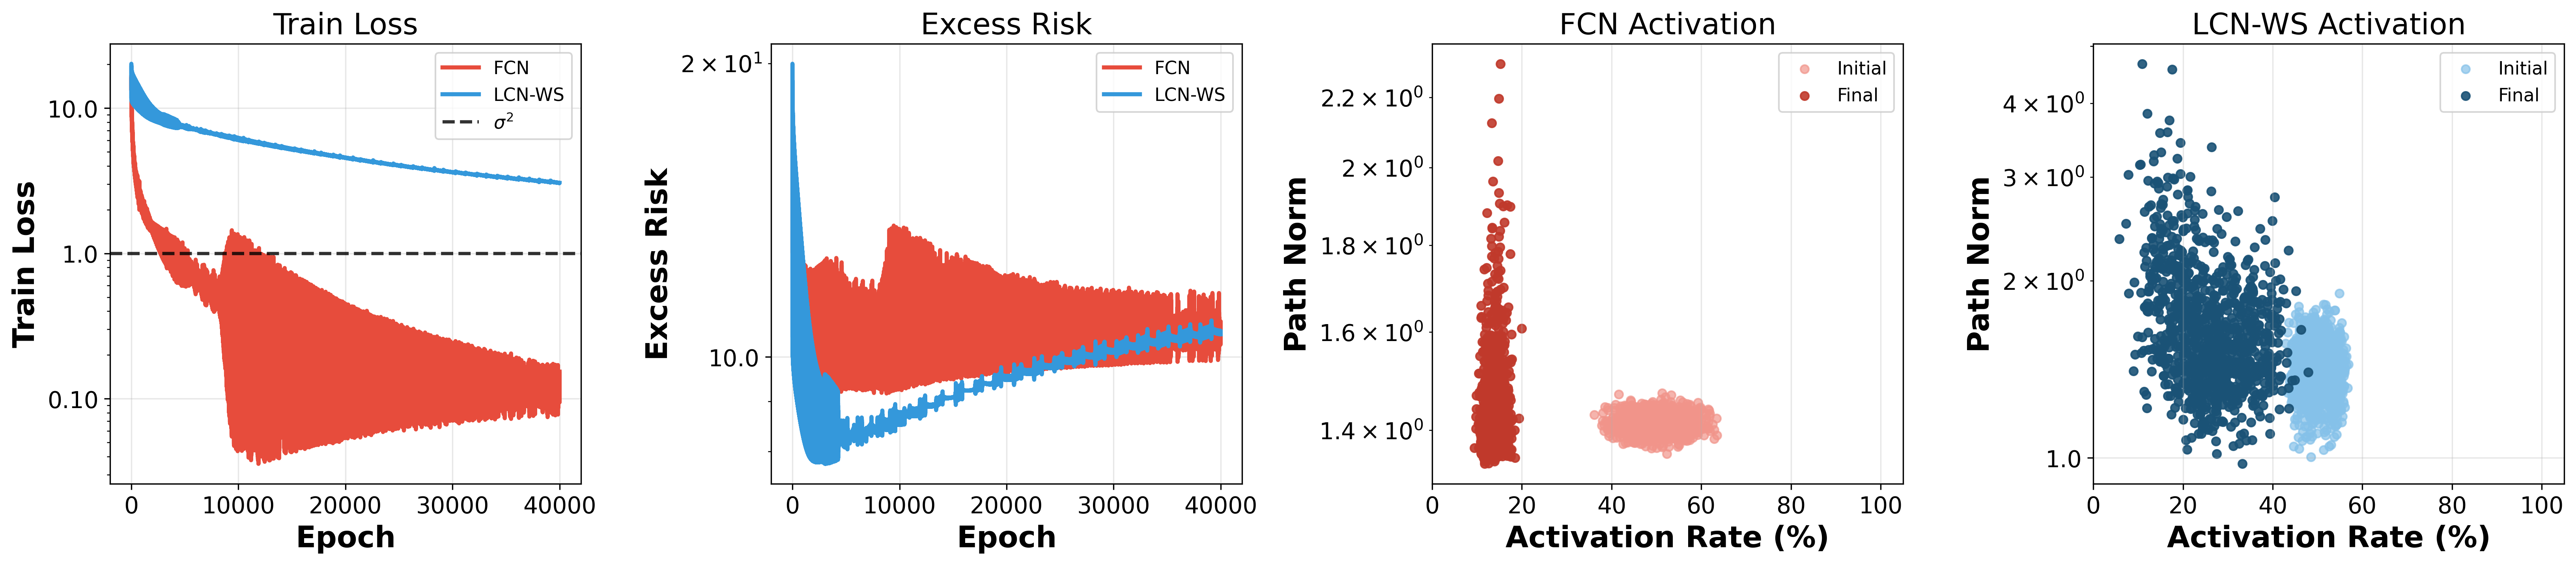


Plot saved to: architecture/cifar_regression_combined.pdf


In [12]:
# =============================================================================
# FINAL PLOT: 4 Subplots (Train Loss + Excess Risk + FCN Activation + LCN-WS Activation)
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
sigma_sq = DATA_CONFIG['sigma'] ** 2

LABEL_SIZE = 18
TICK_SIZE = 14
TITLE_SIZE = 18

epochs_arr = np.arange(TRAIN_CONFIG['epochs'])

# COLOR SCHEME - Red for FCN, Blue for LCN-WS
FCN_COLOR = '#E74C3C'       # Red for FCN
LCN_COLOR = '#3498DB'       # Blue for LCN-WS

# -----------------------------------------------------------------------------
# Subplot 1: Train Loss
# -----------------------------------------------------------------------------
ax = axes[0]

fcn_train_mean = averaged_results['FCN']['train_loss_mean']
fcn_train_std = averaged_results['FCN']['train_loss_std']
ax.semilogy(epochs_arr, fcn_train_mean, '-', color=FCN_COLOR, linewidth=2.5, label='FCN')
ax.fill_between(epochs_arr, np.maximum(fcn_train_mean - fcn_train_std, 1e-10), 
                fcn_train_mean + fcn_train_std, color=FCN_COLOR, alpha=0.2)

lcn_train_mean = averaged_results['LCN-WS']['train_loss_mean']
lcn_train_std = averaged_results['LCN-WS']['train_loss_std']
ax.semilogy(epochs_arr, lcn_train_mean, '-', color=LCN_COLOR, linewidth=2.5, label='LCN-WS')
ax.fill_between(epochs_arr, np.maximum(lcn_train_mean - lcn_train_std, 1e-10),
                lcn_train_mean + lcn_train_std, color=LCN_COLOR, alpha=0.2)

ax.axhline(sigma_sq, color='black', linestyle='--', linewidth=2, alpha=0.8, label=r'$\sigma^2$')

ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Train Loss', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Train Loss', fontsize=TITLE_SIZE)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=TICK_SIZE)
ax.yaxis.set_major_formatter(FuncFormatter(decimal_tick_formatter))

# -----------------------------------------------------------------------------
# Subplot 2: Excess Risk
# -----------------------------------------------------------------------------
ax = axes[1]

fcn_excess_mean = averaged_results['FCN']['excess_risk_mean']
fcn_excess_std = averaged_results['FCN']['excess_risk_std']
ax.semilogy(epochs_arr, fcn_excess_mean, '-', color=FCN_COLOR, linewidth=2.5, label='FCN')
ax.fill_between(epochs_arr, np.maximum(fcn_excess_mean - fcn_excess_std, 1e-10),
                fcn_excess_mean + fcn_excess_std, color=FCN_COLOR, alpha=0.2)

lcn_excess_mean = averaged_results['LCN-WS']['excess_risk_mean']
lcn_excess_std = averaged_results['LCN-WS']['excess_risk_std']
ax.semilogy(epochs_arr, lcn_excess_mean, '-', color=LCN_COLOR, linewidth=2.5, label='LCN-WS')
ax.fill_between(epochs_arr, np.maximum(lcn_excess_mean - lcn_excess_std, 1e-10),
                lcn_excess_mean + lcn_excess_std, color=LCN_COLOR, alpha=0.2)

ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Excess Risk', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Excess Risk', fontsize=TITLE_SIZE)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=TICK_SIZE)
ax.yaxis.set_major_formatter(FuncFormatter(decimal_tick_formatter))

# -----------------------------------------------------------------------------
# Subplot 3: FCN Activation Plot
# -----------------------------------------------------------------------------
ax = axes[2]

FCN_INIT = '#F1948A'      # Light red
FCN_FINAL = '#C0392B'     # Dark red

fcn_init_pn = results['FCN'][0]['hist']['initial_path_norms']
fcn_init_ar = results['FCN'][0]['hist']['initial_act_ratios'] * 100
fcn_final_pn = results['FCN'][0]['hist']['final_path_norms']
fcn_final_ar = results['FCN'][0]['hist']['final_act_ratios'] * 100

ax.scatter(fcn_init_ar, fcn_init_pn, c=FCN_INIT, s=25, alpha=0.7, label='Initial')
ax.scatter(fcn_final_ar, fcn_final_pn, c=FCN_FINAL, s=25, alpha=0.9, label='Final')

ax.set_yscale('log')
ax.set_xlabel('Activation Rate (%)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Path Norm', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('FCN Activation', fontsize=TITLE_SIZE)
ax.set_xlim(0, 105)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=TICK_SIZE)
ax.yaxis.set_major_formatter(FuncFormatter(decimal_tick_formatter))
ax.legend(loc='upper right', fontsize=11)

# -----------------------------------------------------------------------------
# Subplot 4: LCN-WS Activation Plot
# -----------------------------------------------------------------------------
ax = axes[3]

LCN_INIT = '#85C1E9'      # Light blue  
LCN_FINAL = '#1A5276'     # Dark blue

lcn_init_pn = results['LCN-WS'][0]['hist']['initial_path_norms']
lcn_init_ar = results['LCN-WS'][0]['hist']['initial_act_ratios'] * 100
lcn_final_pn = results['LCN-WS'][0]['hist']['final_path_norms']
lcn_final_ar = results['LCN-WS'][0]['hist']['final_act_ratios'] * 100

ax.scatter(lcn_init_ar, lcn_init_pn, c=LCN_INIT, s=25, alpha=0.7, label='Initial')
ax.scatter(lcn_final_ar, lcn_final_pn, c=LCN_FINAL, s=25, alpha=0.9, label='Final')

ax.set_yscale('log')
ax.set_xlabel('Activation Rate (%)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Path Norm', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('LCN-WS Activation', fontsize=TITLE_SIZE)
ax.set_xlim(0, 105)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=TICK_SIZE)
ax.yaxis.set_major_formatter(FuncFormatter(decimal_tick_formatter))
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cifar_regression_combined.pdf', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {SAVE_DIR}/cifar_regression_combined.pdf")

In [13]:
# =============================================================================
# SUMMARY
# =============================================================================
print("="*70)
print("EXPERIMENT SUMMARY")
print("="*70)
print(f"\nSetup:")
print(f"  - CIFAR-10 regression (all 10 classes)")
print(f"  - y = class_label + N(0, σ²), σ = {DATA_CONFIG['sigma']}")
print(f"  - n_train = {DATA_CONFIG['n_train']}, n_test = {DATA_CONFIG['n_test']}")
print(f"  - Seeds: {SEEDS} ({N_SEEDS} seeds for averaging)")
print(f"\nResults (mean ± std over {N_SEEDS} seeds):")
for arch in ARCHITECTURES:
    r = averaged_results[arch]
    print(f"  {arch}:")
    print(f"    Train Loss:  {r['train_loss_mean'][-1]:.4f} ± {r['train_loss_std'][-1]:.4f}")
    print(f"    Excess Risk: {r['excess_risk_mean'][-1]:.4f} ± {r['excess_risk_std'][-1]:.4f}")
print(f"\nσ² = {sigma_sq} (noise variance)")
print("="*70)

EXPERIMENT SUMMARY

Setup:
  - CIFAR-10 regression (all 10 classes)
  - y = class_label + N(0, σ²), σ = 1.0
  - n_train = 1024, n_test = 10000
  - Seeds: [42] (1 seeds for averaging)

Results (mean ± std over 1 seeds):
  FCN:
    Train Loss:  0.1535 ± 0.0000
    Excess Risk: 10.4890 ± 0.0000
  LCN-WS:
    Train Loss:  3.0576 ± 0.0000
    Excess Risk: 10.5473 ± 0.0000

σ² = 1.0 (noise variance)
